In [1]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Debug multi-node HPC? `djaxrun -np 2 python Examples/Sharding/multi_process.py`

NetKet version: 3.21.1.dev13+gbf43effcb


In [2]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

NameError: name 'nn' is not defined

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk

print("=" * 70)
print(">>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设")
print("=" * 70)

class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 1. 强制全局使用 float64，保证行列式求对数的数值稳定性
        dtype = jnp.float64

        # 2. Slater 行列式 (物理层：处理节点面和正负号)
        # 尽管 param_dtype 是实数，NetKet 底层遇到负行列式会自动安全提升为 complex128
        log_slater = nk.models.Slater2nd(
            self.hilbert, 
            generalized=False, 
            restricted=False, 
            param_dtype=dtype
        )(n)

        # 3. Neural Jastrow 因子 (关联层：处理 Hubbard U 和振幅压制)
        x = n.astype(dtype)
        # 第一层：提取轨道间的协同模式
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        # 第二层：压缩为标量能量惩罚/奖励分值
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        # 4. 终极组合：实数关联振幅 + 复数节点相位
        return log_slater + j

print("拟设类 LogNeuralJastrowSlater 编译完成！")

>>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设
拟设类 LogNeuralJastrowSlater 编译完成！


组合 1：Tanh + 强制对称 $F$ (纯 Singlet AGP, 工程极限提速版)

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk

class LogNeuralPfaffianTanhSym(nn.Module):
    """
    组合 1：Tanh 截断 + 强制对称 F (纯 Singlet AGP)
    优化特性：
    1. 彻底无参数冗余：仅声明 N(N+1)/2 个独立参数。
    2. 无矩阵加法对称化：通过高级索引精准镜像填充，杜绝 SR 病态矩阵。
    3. O(N^3) 行列式提速：将 2N 维的 Pfaffian 降维为 N 维行列式。
    """
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int    # 空间总格点数
    n_up: int       # 上自旋电子数
    n_down: int     # 下自旋电子数

    @nn.compact
    def __call__(self, n):
        # [数值稳定性基石] 强制全局使用双精度浮点数
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明独立配对参数 (主对角线 + 严格下三角)
        n_sym_params = self.n_sites * (self.n_sites + 1) // 2
        F_vec = self.param(
            'pairing_vec', 
            nn.initializers.normal(stddev=0.01), 
            (n_sym_params,), 
            dtype
        )
        
        # 2. 从 1D 向量无冗余、无相加地重构严格对称矩阵
        # k=0 提取包含主对角线的下三角索引
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=0)
        F_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        
        # 精准注入：将参数填入下三角，随后将同一批参数按转置索引填入上三角
        # 主对角线被同值覆盖一次，极其高效且安全
        F_sym = F_zeros.at[tril_rows, tril_cols].set(F_vec)
        F_sym = F_sym.at[tril_cols, tril_rows].set(F_vec) 
        
        # 3. [稳定性策略] 强行有界化，压制无穷大导致梯度的 NaN
        F_matrix = jnp.tanh(F_sym)
        
        # 4. 坐标映射与局域配对子矩阵提取
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        # 提取当前构型中被占据的格点索引
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        # 提取跨自旋配对块 (维度为 n_up x n_down)
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        # 兼容 JAX 的批量 (vmap) 计算
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        # 5. [稳定性策略] 动态重标度 (Dynamic Rescaling)
        # 提取子矩阵的最大绝对值 (加上微小常数防除零)，将矩阵规整到 [-1, 1] 区间
        max_val = jnp.max(jnp.abs(sub_F), axis=(-2, -1), keepdims=True) + 1e-12
        sub_F_scaled = sub_F / max_val
        
        # 6. 计算极其稳定的标度化对数行列式
        sign, log_det_scaled = jnp.linalg.slogdet(sub_F_scaled)
        
        # 7. 恢复原始尺度 ( det(A/c) = det(A) / c^N => log|det(A)| = log|det_scaled| + N * log(c) )
        log_max_val = jnp.log(max_val.squeeze(axis=(-2, -1)))
        log_det_true = log_det_scaled + self.n_up * log_max_val
        
        # 8. 结合符号位，输出复数域对数振幅
        log_sign = jnp.log(sign.astype(jnp.complex128))
        return log_det_true + log_sign

组合 2：Tanh + 广义非对称 $F$ (Singlet 混合 Triplet $S_z=0$)

In [ ]:
class LogNeuralPfaffianTanhGen(nn.Module):
    """
    组合 2：Tanh 截断 + 广义非对称 F (Singlet & Triplet S_z=0 混合态)
    优化特性：
    1. 天然无参数冗余：一般非对称方阵本身就需要 N^2 个独立自由度。
    2. 兼容广义配对：不强制对称，波函数可表达非 s-wave/d-wave 的奇宇称分量。
    """
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明完整 N x N 自由度
        F_raw = self.param(
            'pairing_matrix_raw', 
            nn.initializers.normal(stddev=0.01), 
            (self.n_sites, self.n_sites), 
            dtype
        )
        
        # 2. 不对称化：原汁原味地保留 S_z=0 的 Triplet 自由度，仅进行 Tanh 截断
        F_matrix = jnp.tanh(F_raw)
        
        # === 以下与组合 1 的提取与求值逻辑完全一致 ===
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        # 动态重标度
        max_val = jnp.max(jnp.abs(sub_F), axis=(-2, -1), keepdims=True) + 1e-12
        sub_F_scaled = sub_F / max_val
        
        # slogdet 计算
        sign, log_det_scaled = jnp.linalg.slogdet(sub_F_scaled)
        
        log_max_val = jnp.log(max_val.squeeze(axis=(-2, -1)))
        log_det_true = log_det_scaled + self.n_up * log_max_val
        
        log_sign = jnp.log(sign.astype(jnp.complex128))
        return log_det_true + log_sign

组合 3：Expm + 强制对称 $F$ (纯 Singlet, 李代数物理严谨版)

In [ ]:
class LogNeuralPfaffianExpmSym(nn.Module):
    """
    组合 3：李代数 exp(kappa) 轨道旋转 + 强制对称 F (特征值分解)
    优化特性：
    1. 杜绝梯度消失：参数空间在 O(1) 量级平稳流动。
    2. 无冗余李代数生成元：通过上下三角反号填充，替代耗时且引发病态的 (k - k.T)。
    3. 天然良态：U \Lambda U^T 构造出的 F 矩阵绝对不会导致 SVD 崩溃。
    """
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 对角配对本征振幅 Lambda (长度为 N_sites)
        lambdas = self.param(
            'pairing_eigenvalues',
            nn.initializers.normal(stddev=0.1),
            (self.n_sites,), dtype
        )
        
        # 2. 生成元 kappa 的独立参数 (仅非对角，数量 N(N-1)/2)
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_vec = self.param(
            'kappa_vec',
            nn.initializers.normal(stddev=0.01),
            (n_kappa,), dtype
        )
        
        # 3. [核心优化] 极致的无冗余反对称矩阵构造
        # k=-1 提取严格下三角索引 (避开主对角线)
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        
        # 下三角填入正参数，上三角通过索引翻转填入负参数！
        # 主对角线天然保持绝对的 0.0，完美满足李代数 so(N) 的要求
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        # 4. 轨道正交旋转矩阵 U = exp(kappa)
        U = jax.scipy.linalg.expm(kappa)
        
        # 5. 构造对称的全局配对矩阵 F = U * diag(lambda) * U^T
        F_matrix = jnp.dot(U * lambdas, U.T)
        
        # === 坐标映射与局域配对子矩阵提取 ===
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        # 6. 计算标度化对数行列式 (因为特征值分解天然良态，不再需要 Tanh 版的强制重标度)
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_sign = jnp.log(sign.astype(jnp.complex128))
        return log_det + log_sign

组合 4：Expm + 广义非对称 $F$ (SVD 李群参数化版)

In [ ]:
class LogNeuralPfaffianExpmGen(nn.Module):
    """
    组合 4：李代数 exp(kappa) + 广义非对称 F (奇异值分解 SVD 参数化)
    优化特性：
    1. 完美匹配自由度：左旋转(N(N-1)/2) + 右旋转(N(N-1)/2) + 奇异值(N) = N^2，精确映射任意矩阵。
    2. 物理稳定性极致：双独立生成元构造，在彻底杜绝冗余的同时，实现广义配对探索。
    """
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. SVD 中的奇异值 Sigma (对角线权重)
        sigmas = self.param(
            'pairing_singular_values',
            nn.initializers.normal(stddev=0.1),
            (self.n_sites,), dtype
        )
        
        # 2. 声明左右两个独立的旋转生成元向量 (完全解耦 U 和 V)
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_U_vec = self.param('kappa_U_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        kappa_V_vec = self.param('kappa_V_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        # 3. [核心优化] 分别重构两个无冗余的反对称矩阵
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        
        kappa_U = zeros.at[tril_rows, tril_cols].set(kappa_U_vec)
        kappa_U = kappa_U.at[tril_cols, tril_rows].set(-kappa_U_vec)
        
        kappa_V = zeros.at[tril_rows, tril_cols].set(kappa_V_vec)
        kappa_V = kappa_V.at[tril_cols, tril_rows].set(-kappa_V_vec)
        
        # 4. 计算左右正交矩阵，并组装广义非对称配对矩阵 F = U * diag(sigma) * V^T
        U = jax.scipy.linalg.expm(kappa_U)
        V = jax.scipy.linalg.expm(kappa_V)
        
        F_matrix = jnp.dot(U * sigmas, V.T)
        
        # === 坐标映射与局域配对子矩阵提取 ===
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        # 5. SVD 构造天然极度稳定，直接获取对数行列式
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_sign = jnp.log(sign.astype(jnp.complex128))
        return log_det + log_sign

chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


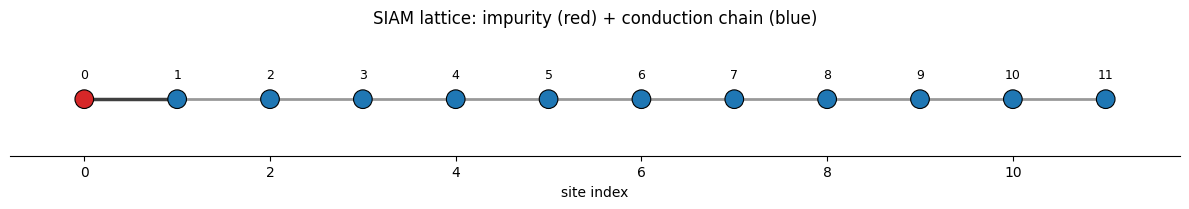

In [ ]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

h_pin = 0.01
H -= h_pin * 0.5 * (n_d_up - n_d_dn)
# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -14.207971825170223
Lowest 4 eigenvalues = [-14.20797183 -14.19545892 -13.69079971 -13.69064823]


In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


In [ ]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralPfaffianExpmSym(hi,12,6,6)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================



gs_nj = nk.driver.VMC_SR(
    H,          # 【注意】：这里传入的是加上了外场的新哈密顿量
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural NeuralPfaffianExpmSym optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 78 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [02:37<00:00,  1.27it/s, Energy=-9.953+0.000j ± 0.045 [σ²=5.5e+00, R̂=1.005]] 


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -10.486-0.000j ± 0.048 [σ²=4.8e+00, R̂=1.013]


In [37]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogSlaterDeterminant(hi)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================



gs_nj = nk.driver.VMC_SR(
    H,          # 【注意】：这里传入的是加上了外场的新哈密顿量
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural LogSlaterDeterminant optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 72 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [02:32<00:00,  1.31it/s, Energy=-13.335-0.000j ± 0.015 [σ²=1.0e+00, R̂=1.003]]


----------------------------------------------------------------------
Neural LogSlaterDeterminant optimized energy: -13.347-0.000j ± 0.015 [σ²=1.0e+00, R̂=1.002]


In [39]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=8)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**13,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================


gs_nj = nk.driver.VMC_SR(
    H,          # 【注意】：这里传入的是加上了外场的新哈密顿量
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.005,  # 小的对角线平移，增强数值稳定性
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=200, out=nj_log)

# 【注意】：测量最终能量时，也需要用加上 pinning field 的 H_pinned
E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 353 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 200/200 [03:27<00:00,  1.04s/it, Energy=-14.20744+0.00000j ± 0.00020 [σ²=2.8e-04, R̂=1.001]]


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -14.20749-0.00000j ± 0.00022 [σ²=3.4e-04, R̂=1.000]
